<a href="https://colab.research.google.com/github/vneumannufprbr/TrabajosenPython/blob/main/Cuaderno_de_An%C3%A1lisis_Validaci%C3%B3n_Predicci%C3%B3n_con_XGBoost_Ok_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Librerías importadas correctamente.
Datos cargados exitosamente con 14 tipos de incidentes.

¿Qué desea hacer? Ingrese 'analizar', 'validar' o 'predecir': predecir

INICIANDO MODO PRODUCCIÓN (ENTRENAMIENTO Y PREDICCIÓN)

--- Entrenando modelo de producción para 'Abigeato' ---
Datos insuficientes. No se guardará el modelo.

--- Entrenando modelo de producción para 'Coaccion sexual' ---
Datos insuficientes. No se guardará el modelo.

--- Entrenando modelo de producción para 'Homicidio culposo en accidente de transito' ---
Modelo de producción guardado en: modelos_guardados/modelo_homicidio_culposo_en_accidente_de_transito.joblib

--- Entrenando modelo de producción para 'Homicidio doloso' ---
Datos insuficientes. No se guardará el modelo.

--- Entrenando modelo de producción para 'Hurto' ---
Modelo de producción guardado en: modelos_guardados/modelo_hurto.joblib

--- Entrenando modelo de producción para 'Hurto agravado' ---
Modelo de producción guardado en: modelos_guardados/modelo_hurto

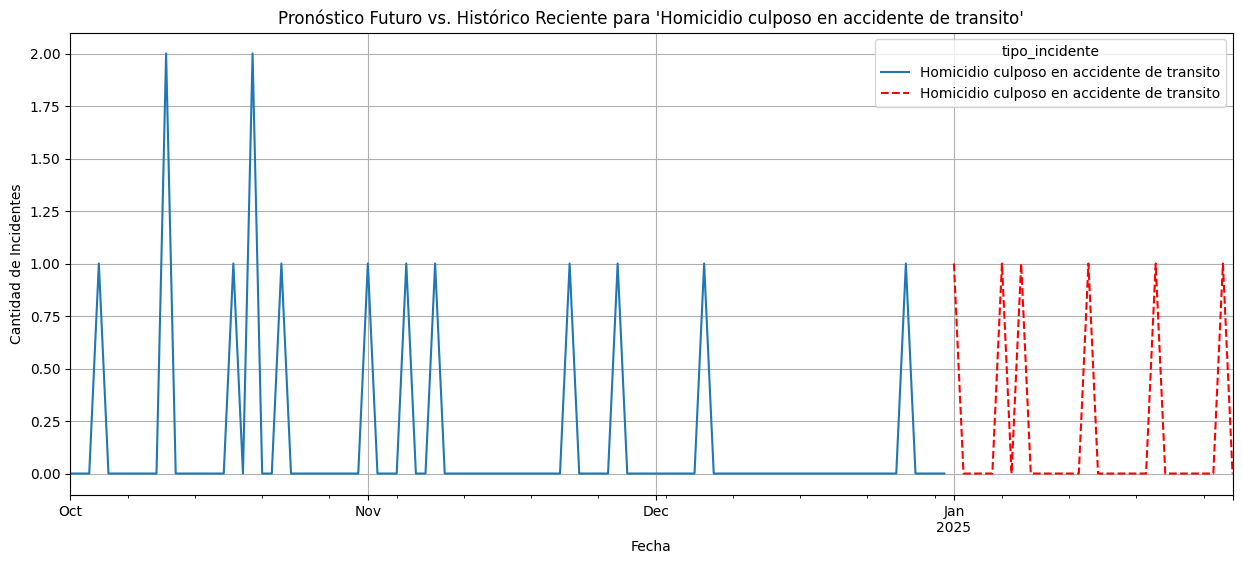

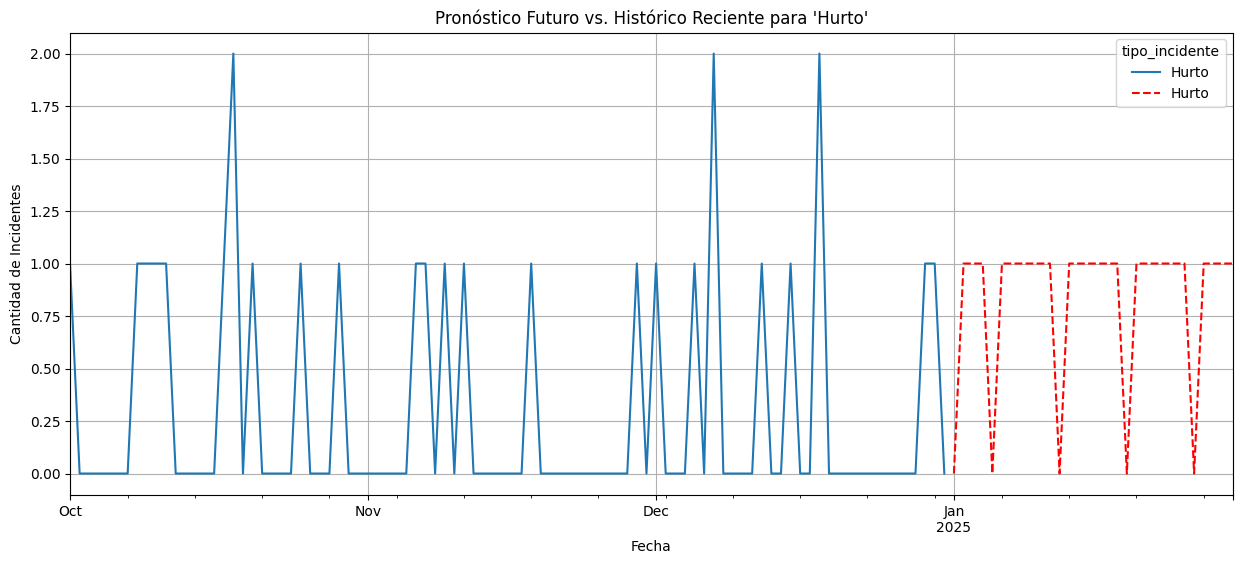

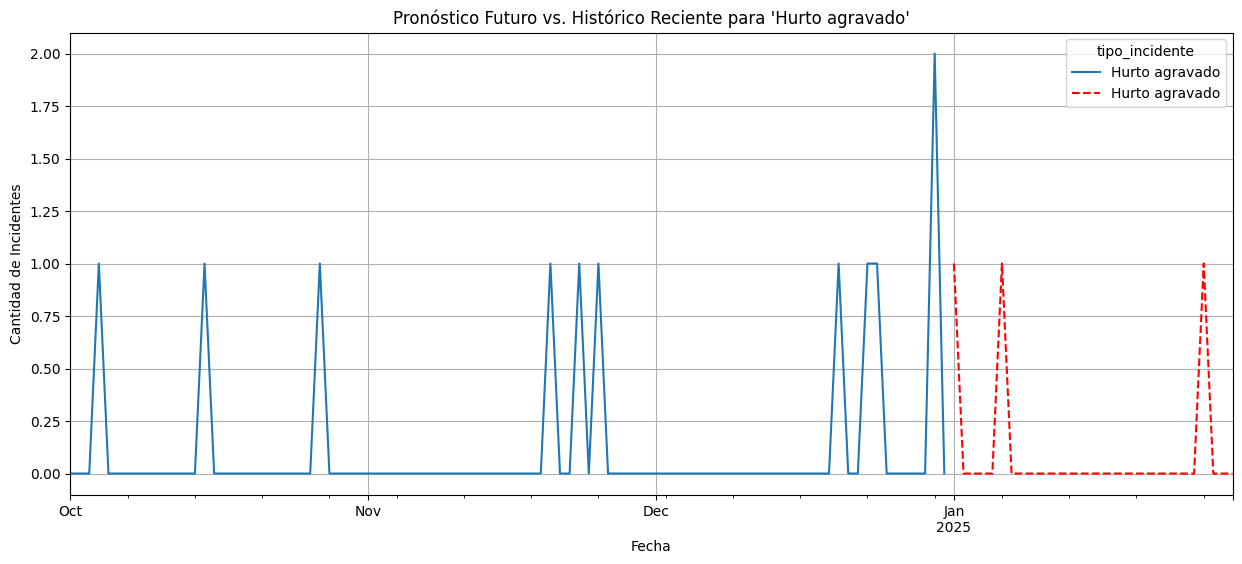

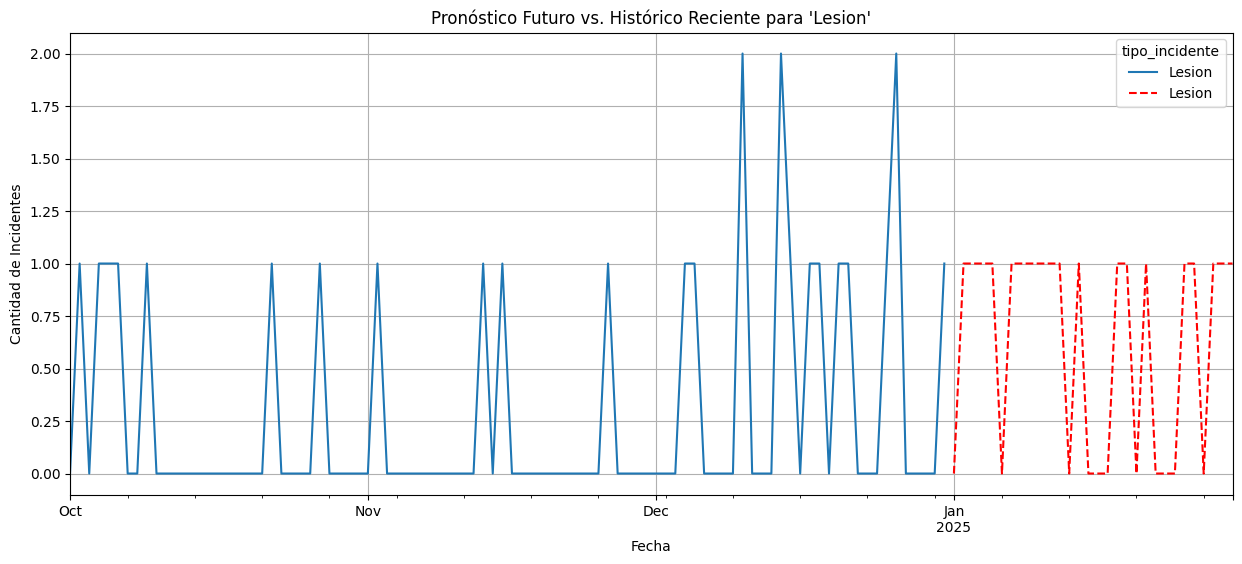

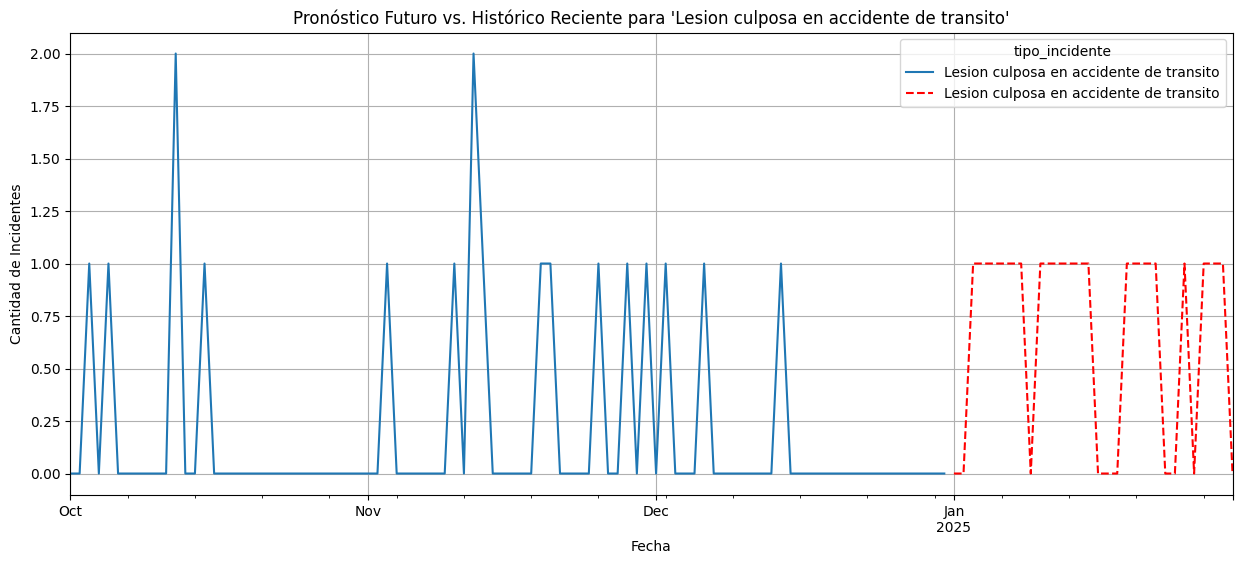

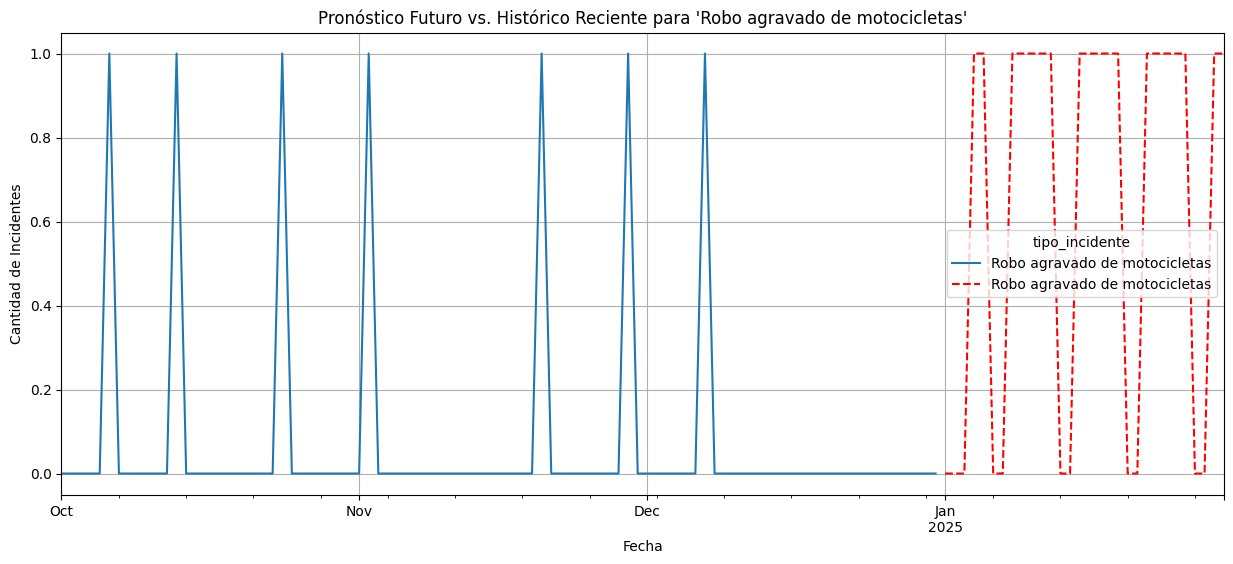

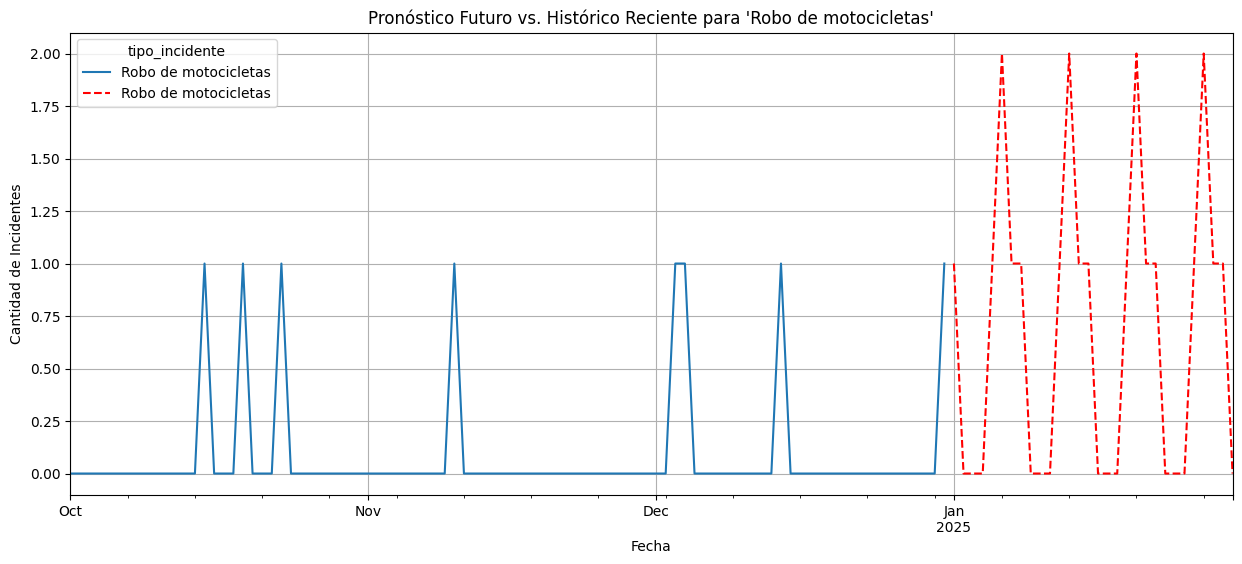

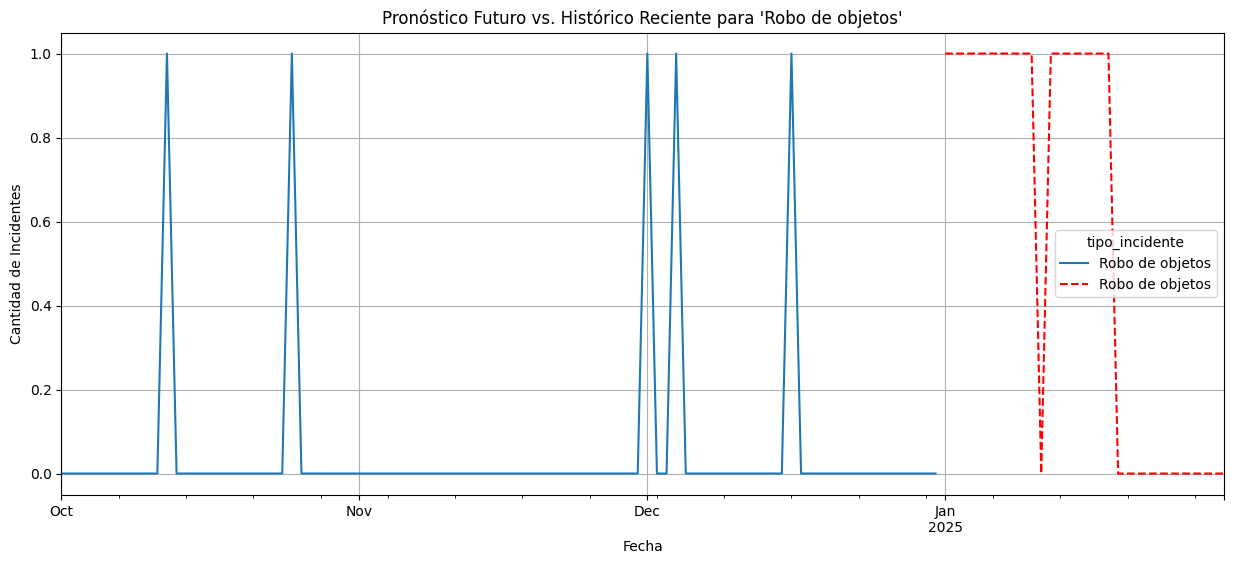

In [3]:
# -*- coding: utf-8 -*-
"""
Cuaderno de Análisis y Predicción Completo (XGBoost)
Versión 1.0 - Con los 3 Modos (analizar, validar, predecir) Funcionales

Objetivo: Ofrecer un flujo de trabajo completo que permita el análisis de
          series temporales (ACF/PACF), la validación de modelos (backtesting)
          y la generación de pronósticos de producción.
"""

# -----------------------------------------------------------------------------
# Paso 1: Importación de Librerías
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import xgboost as xgb
import holidays
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
print("Librerías importadas correctamente.")

# -----------------------------------------------------------------------------
# --- CONFIGURACIÓN DE PARÁMETROS ---
# -----------------------------------------------------------------------------
ROLLING_WINDOW_SIZE = 7 # Probar 1, 7 y 14 # Probar valores más altos con más datos
LAGS_TO_PLOT = 40

# -----------------------------------------------------------------------------
# Paso 2: Funciones Comunes
# -----------------------------------------------------------------------------

def crear_caracteristicas(dataframe, target_column=None, window_size=7):
    """Crea características de series temporales."""
    df_copy = dataframe.copy()
    df_copy['dia_de_la_semana'] = df_copy.index.dayofweek
    df_copy['mes'] = df_copy.index.month
    df_copy['anio'] = df_copy.index.year
    df_copy['dia_del_anio'] = df_copy.index.dayofyear
    df_copy['semana_del_anio'] = df_copy.index.isocalendar().week.astype(int)
    py_holidays = holidays.Paraguay(years=df_copy.index.year.unique())
    df_copy['es_feriado'] = df_copy.index.isin(py_holidays).astype(int)
    if target_column:
        df_copy['lag1'] = df_copy[target_column].shift(1)
        df_copy['lag7'] = df_copy[target_column].shift(7)
        df_copy[f'rolling_mean_{window_size}'] = df_copy[target_column].rolling(window=window_size).mean()
    return df_copy

# -----------------------------------------------------------------------------
# --- MODO ANÁLISIS ---
# -----------------------------------------------------------------------------

def analizar_series_temporales(dataframe, lags):
    """Genera gráficos ACF y PACF para cada tipo de incidente."""
    print("\n" + "="*70)
    print("INICIANDO MODO ANÁLISIS (ACF/PACF)")
    print("="*70)
    for incidente in dataframe.columns:
        print(f"\n--- Análisis para: '{incidente}' ---")
        if dataframe[incidente].sum() < 20:
            print("Datos insuficientes para un análisis de autocorrelación significativo.")
            continue
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        plot_acf(dataframe[incidente], ax=ax1, lags=lags)
        ax1.set_title(f'Función de Autocorrelación (ACF) para {incidente}')
        ax1.grid(True)
        plot_pacf(dataframe[incidente], ax=ax2, lags=lags)
        ax2.set_title(f'Función de Autocorrelación Parcial (PACF) para {incidente}')
        ax2.grid(True)
        plt.tight_layout()
        plt.show()

# -----------------------------------------------------------------------------
# --- MODO VALIDACIÓN ---
# -----------------------------------------------------------------------------

def validar_modelo(dataframe, target_column, window_size):
    """Entrena, evalúa y muestra la importancia de las variables de un modelo."""
    print("-" * 70)
    print(f"VALIDANDO MODELO PARA: '{target_column}' (Ventana de {window_size} días)")

    df_model = crear_caracteristicas(dataframe[[target_column]], target_column, window_size).dropna()
    fecha_corte = df_model.index.max() - pd.DateOffset(months=3)
    train_df, test_df = df_model.loc[df_model.index <= fecha_corte], df_model.loc[df_model.index > fecha_corte]

    if test_df.empty or train_df.empty or train_df[target_column].sum() < 10:
        print(f"Datos insuficientes para validar.")
        return None

    features = [col for col in train_df.columns if col != target_column]
    X_train, y_train, X_test, y_test = train_df[features], train_df[target_column], test_df[features], test_df[target_column]

    reg = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5, early_stopping_rounds=20, objective='reg:squarederror', random_state=42) # Modelado con XGBoost
    reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

    y_pred = reg.predict(X_test)
    rmse, r2 = np.sqrt(mean_squared_error(y_test, y_pred)), r2_score(y_test, y_pred)

    print(f"\nRESULTADOS DE VALIDACIÓN:\n  - RMSE: {rmse:.2f} | R² (Precisión): {r2:.2f}")

    feature_importance = pd.DataFrame(data=reg.feature_importances_, index=reg.feature_names_in_, columns=['Importancia']).sort_values('Importancia', ascending=False)

    # Aplicar traducciones para impresión, manejando posibles traducciones faltantes
    traducciones = {'dia_de_la_semana': 'Día de la Semana', 'mes': 'Mes del Año', 'anio': 'Año', 'dia_del_anio': 'Día del Año', 'semana_del_anio': 'Semana del Año', 'es_feriado': 'Es Feriado', 'lag1': 'Delitos (Día Anterior)', 'lag7': 'Delitos (Semana Anterior)', f'rolling_mean_{window_size}': f'Promedio Móvil ({window_size} Días)'}
    translated_index = feature_importance.index.map(traducciones)
    # Usar fillna en una Serie con el índice original como una Serie
    feature_importance_translated = feature_importance.copy()
    feature_importance_translated.index = pd.Series(translated_index).fillna(pd.Series(feature_importance.index))


    print("\nIMPORTANCIA DE VARIABLES PARA ESTE MODELO:")
    print(feature_importance_translated.head(5))
    print("-" * 70)

    test_df['prediccion'] = y_pred
    fig, ax = plt.subplots(figsize=(15, 6))
    train_df.loc[train_df.index > fecha_corte - pd.DateOffset(months=9)][target_column].plot(ax=ax, label='Datos de Entrenamiento', legend=True)
    test_df[target_column].plot(ax=ax, label=f'Datos Reales ({target_column})', legend=True)
    test_df['prediccion'].plot(ax=ax, label=f'Predicciones ({target_column})', legend=True, color='red', linestyle='--')
    ax.set_title(f"Validación de Pronóstico para '{target_column}'")
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Cantidad de Incidentes')
    ax.grid(True)
    plt.show()

    return feature_importance_translated

# -----------------------------------------------------------------------------
# --- MODO PRODUCCIÓN ---
# -----------------------------------------------------------------------------

def entrenar_y_guardar_modelo(dataframe, target_column, model_path, window_size):
    """Entrena un modelo con TODOS los datos disponibles y lo guarda."""
    print(f"\n--- Entrenando modelo de producción para '{target_column}' ---")
    df_model_full = crear_caracteristicas(dataframe[[target_column]], target_column, window_size).dropna()
    if df_model_full.empty or df_model_full[target_column].sum() < 20:
        print(f"Datos insuficientes. No se guardará el modelo.")
        return
    features = [col for col in df_model_full.columns if col != target_column]
    X_train_full, y_train_full = df_model_full[features], df_model_full[target_column]
    reg = xgb.XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=5, objective='reg:squarederror', random_state=42) # Modelado con XGBoost con datos completos
    reg.fit(X_train_full, y_train_full, verbose=False)
    joblib.dump(reg, model_path)
    print(f"Modelo de producción guardado en: {model_path}")

def cargar_y_predecir(model_path, historical_df, future_dates, window_size):
    """Carga un modelo guardado y predice sobre fechas futuras."""
    try:
        model = joblib.load(model_path)
    except FileNotFoundError:
        return None
    df_future_with_history = pd.concat([historical_df, pd.DataFrame(index=future_dates)])
    df_features_full = crear_caracteristicas(df_future_with_history, historical_df.columns[0], window_size)
    X_future = df_features_full.loc[future_dates]
    X_future_final = X_future[model.get_booster().feature_names]
    predictions = model.predict(X_future_final)
    return np.round(np.maximum(0, predictions)).astype(int)

# =============================================================================
# --- PUNTO DE ENTRADA PRINCIPAL ---
# =============================================================================

if __name__ == '__main__':
    try:
        df_incidents = pd.read_csv('incidentes_simulados_restricciones.csv', encoding='utf-8')
        df_incidents['fecha'] = pd.to_datetime(df_incidents['fecha'])
        df_pivot = pd.pivot_table(df_incidents, index='fecha', columns='tipo_incidente', aggfunc='size', fill_value=0)
        date_rng = pd.date_range(start=df_pivot.index.min(), end=df_pivot.index.max(), freq='D')
        df_granular = df_pivot.reindex(date_rng, fill_value=0)
        print(f"Datos cargados exitosamente con {len(df_granular.columns)} tipos de incidentes.")
    except FileNotFoundError:
        print("\nERROR: El archivo 'incidentes_simulados_restricciones.csv' no se encontró.")
        exit()

    while True:
        modo = input("\n¿Qué desea hacer? Ingrese 'analizar', 'validar' o 'predecir': ").lower().strip()
        if modo in ['analizar', 'validar', 'predecir']:
            break
        else:
            print("Entrada no válida. Por favor, intente de nuevo.")

    if modo == 'analizar':
        analizar_series_temporales(df_granular, lags=LAGS_TO_PLOT)

    elif modo == 'validar':
        print("\n" + "="*70)
        print("INICIANDO MODO VALIDACIÓN (BACKTESTING)")
        print("="*70)
        importancia_total = []
        for incidente in df_granular.columns:
            importancia = validar_modelo(df_granular, incidente, window_size=ROLLING_WINDOW_SIZE)
            if importancia is not None:
                importancia['tipo_incidente'] = incidente
                importancia_total.append(importancia)
        if importancia_total:
            df_importancia_total = pd.concat(importancia_total).reset_index().rename(columns={'index': 'feature'})
            # Aplicar el mapeo de traducción a la columna 'feature'
            traducciones = {'dia_de_la_semana': 'Día de la Semana', 'mes': 'Mes del Año', 'anio': 'Año', 'dia_del_anio': 'Día del Año', 'semana_del_anio': 'Semana del Año', 'es_feriado': 'Es Feriado', 'lag1': 'Delitos (Día Anterior)', 'lag7': 'Delitos (Semana Anterior)', f'rolling_mean_{ROLLING_WINDOW_SIZE}': f'Promedio Móvil ({ROLLING_WINDOW_SIZE} Días)'}

            df_importancia_total['feature'] = df_importancia_total['feature'].map(traducciones).fillna(df_importancia_total['feature'])

            plt.figure(figsize=(12, 8))
            sns.barplot(x='Importancia', y='feature', data=df_importancia_total.groupby('feature')['Importancia'].mean().sort_values(ascending=False).reset_index(), palette='viridis')
            plt.title('Importancia Promedio de las Variables (Todos los Modelos)')
            plt.xlabel('Nivel de Importancia Promedio')
            plt.ylabel('Variable Predictora')
            plt.tight_layout()
            plt.show()

    elif modo == 'predecir':
        print("\n" + "="*70)
        print("INICIANDO MODO PRODUCCIÓN (ENTRENAMIENTO Y PREDICCIÓN)")
        print("="*70)
        model_dir = "modelos_guardados"
        if not os.path.exists(model_dir):
            os.makedirs(model_dir)

        for incidente in df_granular.columns:
            model_path = os.path.join(model_dir, f"modelo_{incidente.lower().replace(' ', '_')}.joblib")
            entrenar_y_guardar_modelo(df_granular, incidente, model_path, window_size=ROLLING_WINDOW_SIZE)

        while True:
            try:
                dias_str = input("\n¿Cuántos días hacia el futuro desea predecir? (1-90): ")
                dias_a_predecir = int(dias_str)
                if 1 <= dias_a_predecir <= 90: break
                else: print("Error: Por favor, ingrese un número entre 1 y 90.")
            except ValueError:
                print("Error: Entrada no válida. Ingrese un número entero.")

        last_known_date = df_granular.index.max()
        future_dates = pd.date_range(start=last_known_date + pd.Timedelta(days=1), periods=dias_a_predecir, freq='D')
        df_pronostico_total = pd.DataFrame(index=future_dates)

        print(f"\nGenerando pronóstico para los próximos {dias_a_predecir} días...")

        for incidente in df_granular.columns:
            model_path = os.path.join(model_dir, f"modelo_{incidente.lower().replace(' ', '_')}.joblib")
            predicciones = cargar_y_predecir(model_path, df_granular[[incidente]], future_dates, window_size=ROLLING_WINDOW_SIZE)
            if predicciones is not None:
                df_pronostico_total[incidente] = predicciones

        df_pronostico_final = df_pronostico_total.fillna(0).astype(int)

        print("\n" + "-"*70)
        print(f"RESULTADO FINAL: TABLA DE PRONÓSTICO")
        print("-" * 70)
        print(df_pronostico_final)

        output_filename = 'pronostico_futuro.csv'
        df_pronostico_final.to_csv(output_filename, encoding='utf-8')
        print(f"\n¡Éxito! El pronóstico ha sido guardado en: '{output_filename}'")

        print("\n" + "="*70)
        print("GENERANDO GRÁFICOS DE PRONÓSTICO FUTURO")
        print("="*70)
        for incidente in df_pronostico_final.columns:
            if incidente in df_granular.columns:
                fig, ax = plt.subplots(figsize=(15, 6))
                historial_reciente = df_granular.loc[df_granular.index > last_known_date - pd.DateOffset(months=3)][[incidente]]
                historial_reciente.plot(ax=ax, label=f'Histórico Real ({incidente})', legend=True)
                df_pronostico_final[[incidente]].plot(ax=ax, label=f'Pronóstico Futuro ({incidente})', legend=True, color='red', linestyle='--')
                ax.set_title(f"Pronóstico Futuro vs. Histórico Reciente para '{incidente}'")
                ax.set_xlabel('Fecha')
                ax.set_ylabel('Cantidad de Incidentes')
                ax.grid(True)
                plt.show()